Functions needed to precondition CG with preconditioner as described in "Fast Iteratively Reweighted Least Squares Algorithms for Analysis-Based Sparsity Reconstruction"


Function that creates a, b, c as in Figure (41)
Function that solves lower triangular system with input the diagonals
Function that solves upper triangular system with input the diagonals

In [1]:
# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.algorithms import FISTA

from cil.plugins.ccpi_regularisation.functions import FGP_TV

from cil.optimisation.functions import LeastSquares, BlockFunction, L2NormSquared, IndicatorBox, TotalVariation
from cil.optimisation.utilities import callbacks

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, GradientOperator, \
                                        CompositionOperator, ZeroOperator, MaskOperator

In [2]:
def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device='cpu')

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom

def add_poss_noise(background_counts, n_angles, n_pixels):
    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss

#A, sino, ig, ag, phantom = get_A(20, 100)


Computing $\overline{A^TA}$

In [3]:
def mean_ATA(A, n_pixels):
    """
    A is a ProjectionOperator
    """
    two_norm = L2NormSquared()
    get_ig = A.domain_geometry()

    sum = 0
    for k in range(3):

        # generate random entries
        xk = np.random.normal(0, 1, (n_pixels, n_pixels))

        # put random entries in class <DataContainer>
        xk_datacon = get_ig.allocate()
        xk_datacon.fill(xk)

        # compute 
        yk = A.direct(xk_datacon)
        sum += two_norm(yk)
    
    final = (1/3)*sum
    final_mean = (1/(n_pixels**2)) * final
    return final_mean

## Preconditioning the TV norm

Solving LU

In [4]:
def create_abs(weights, n, ATAI_mean, alpha, vox_size):
    """
    Creates the entries of the matrix in figure (41) in the article 'Fast Iteratively Reweighted Least Squares
    Algorithms for Analysis-Based Sparsity Reconstruction'

    INPUT
        n: number of pixels (n_pixels)
        A: ProjectionOperator
        weights: weights in np.array(), not flattened

    OUTPUT
        a: diagonal elements of figure (41)
        b: lower- and upperdiagonal elements of figure (41)
        c: offdiagonal elements of figure (41)
    """

    weights_arr = weights.as_array()
    w = weights_arr.flatten()
    N_big = n**2

    a = np.zeros(N_big)
    b = np.zeros(N_big - 1)

    for i in range(n):
        k = i * n
        if i == 0:
            a[k: k + n] = w[k: k + n]
            a[k: k + n - 1] += w[k: k + n - 1]
            a[k + 1: k + n] += w[k: k + n - 1]
            b[k: k + n - 1] = -w[k: k + n - 1]
        elif i == n-1:
            a[k: k + n] = w[k - n: k]
            a[k: k + n - 1] += w[k: k + n - 1]
            a[k + 1: k + n] += w[k: k + n - 1]
            b[k: k + n - 1] = -w[k: k + n - 1]
        else:
            a[k: k + n] = w[k: k + n] + w[k - n: k]
            a[k: k + n - 1] += w[k: k + n - 1]
            a[k + 1: k + n] += w[k: k + n - 1]
            b[k: k + n - 1] = -w[k: k + n - 1]


    mult_fac = alpha * ((1 / vox_size) ** 2) 

    a_final = mult_fac * a + ATAI_mean

    # creating offdiagonal elements
    c = (-weights_arr.flatten())[:N_big - n]
    
    b *= mult_fac
    c *= mult_fac

    return a_final, b, c

def solve_Ux(diag, updiag, offdiag, y):
    """

    Solves Ux = y, if the matrix U is upper triangular and 
    has the form as in figure (43)
    
    INPUT:
        diag: diagonal elements of U (np.array())
        updiag: upper diagonal elements of U (np.array())
        offdiag: off diagonal elements of U (np.array())
        y: known vector (np.array())

    OUTPUT:
        x: solution to Ux = y (np.array())

    """

    # relation between N and n is given in the article
    N_big = len(diag)
    n = int(np.sqrt(N_big))

    x = np.zeros(N_big)
    x[-1] = y[-1] / diag[-1]    

    # loop over entries of x, first element last
    for i in range(2, N_big + 1):   
        k = N_big - i
        
        # if statements since only part of the entries of x are affected by offdiagonal entries
        if k >= N_big - n:   
            #print("first if", N_big - i)
            x[k] = (1 / diag[k]) * (y[k] - updiag[k]*x[k + 1])
        if k < N_big - n:
            #print("second if", N_big - i)
            x[k] = (1 / diag[k]) * (y[k] - updiag[k]*x[k + 1] - offdiag[k] * x[k + n])

    return x

def solve_Lx(lowdiag, offdiag, y):

    """ 
    solves Lx = y, with L lower triangular and in the from of figure (42)

    INPUT:
        lowdiag: lower diagonal entries (np.array())
        offdiag: offdiagonal entries (np.array())
        y: known vector (np.array())

    OUTPUT:
        x: solution to Lx = y (np.array())
    """
    
    # relation between N and n is given in the article
    N_big = len(y)
    n = int(np.sqrt(N_big))

    x = np.zeros(N_big)
    x[0] = y[0]

    # loop over the entries of x
    for i in range(1, N_big):

        # if statements, since the offdiagonal entries only influence part of x
        if i < n:
            x[i] = y[i] - lowdiag[i - 1]*x[i - 1]
        if i >= n:
            x[i] = y[i] - lowdiag[i - 1]*x[i - 1] - offdiag[i - n]*x[i - n]

    return x

def solve_Pxy(P_a, P_b, P_c, y):
    
    """
    solves Px = y, with P the matrix as in figure (41) of the article 
    'Fast Iteratively Reweighted Least Squares Algorithms for Analysis-Based 
    Sparsity Reconstruction'. P has an known incomplete LU decomposition. 

    INPUT:
        P_a: diagonal elements of the matrix in figure (41) (np.array())
        P_b: lower- and upperdiagonal elements of the matrix in figure (41) (np.array())
        P_c: offdiagonal elements of the matrix in figure (41) (np.array())
        y: known in Px = y (ImageData)
    
    OUTPUT:
        x: solution of Px = y (ImageData) 
        NOTE: is currently NOT ImageData, but an np.array()
    """

    L_lowdiag = P_b / P_a[:-1]
    L_offdiag = P_c / P_a[:len(P_c)]

    sol = y.copy()
    
    y_arr = y.as_array()
    n = len(y_arr)
    y_flat = y_arr.flatten()

    temp_solve = solve_Lx(L_lowdiag, L_offdiag, y_flat)
    x = solve_Ux(P_a, P_b, P_c, temp_solve)
    
    x_reshape = np.reshape(x, (n, n))
    sol.fill(x_reshape)

    return sol

CG functions

In [5]:
def apply_operator_tv(x, W, A, alpha):
    
    """
    Applies the operator 
    
    A^TA + alpha *D^T*W_b*D
    
    to the input ImageData x. Used to solve the normal equations 

    (A^TA + alpha * D^T*W_b*D)u = A^Ty

    with W_b = [[W 0],
                [0, W]]
                      
    and W = diag{weights_k}

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights for in W
        A:  Projection operator
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * D^T*W_b*D)x
    """

    get_ig = A.domain_geometry()
    grad_operator = GradientOperator(get_ig)
    diagonal_weights = DiagonalOperator(W)

    # z1 = Dx
    z1 = grad_operator.direct(x)

    # z2 = Wtilde z1
    z2_a = diagonal_weights.direct(z1[0])
    z2_b = diagonal_weights.direct(z1[1])
    z2 = BlockDataContainer(z2_a, z2_b)

    #z3 = D^T z2 = D^T*Wtilde*Dx
    z3 = grad_operator.adjoint(z2)

    # y2 = A^TAx
    y1 = A.direct(x)
    y2 = A.adjoint(y1)

    final = y2 + alpha * z3

    return final

def CG(initial, max_iter, A, ATb, alpha, Wk, cg_tol, apply_operator):

    """
    Solves for u in the system 

    (apply_operator)u = A^Tb

    using CG

    """

    u0 = initial.copy()
    r0 = ATb - apply_operator(x=u0, W=Wk, A=A, alpha=alpha)
    p0 = r0
    
    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    cg_tol *= 2
    rel_tol = r0_norm * cg_tol

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # counting inner iterations
    inner_iter_count = max_iter

    # perform CG iterations
    for k in range(max_iter):

        # zk = Apk
        zk = apply_operator(x=pk, W=Wk, A=A, alpha=alpha)

        alpha_k = delta_new/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)
        conv_arr.append(check)
        if check < rel_tol:
            uk = uk_plus_one
            inner_iter_count = k + 1
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk, conv_arr, inner_iter_count

def CG_tv_preconditioned(initial, max_iter, A, ATb, alpha, Wk, cg_tol, ATAI_mean, vox_size):
    """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG

    preconditioned

    """

    u0 = initial.copy()
    r0 = ATb - apply_operator_tv(u0, Wk, A, alpha)

    n_pixels = int(np.sqrt(np.size(u0)))
    P_a, P_b, P_c = create_abs(Wk, n_pixels, ATAI_mean, alpha, vox_size)
    w0 = solve_Pxy(P_a, P_b, P_c, r0)
    p0 = w0

    # set initials, note these are all of class <ImageData>
    wk = w0
    pk = p0
    uk = u0
    rk = r0

    delta_new = rk.dot(wk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    cg_tol *= 2
    rel_tol = cg_tol * r0_norm

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # counting inner iterations
    inner_iter_count = max_iter

    # perform CG iterations
    for k in range(max_iter):

        zk = apply_operator_tv(pk, Wk, A, alpha)

        alpha_k = delta_new / (pk.dot(zk.conjugate()))

        uk_plus_one = uk + alpha_k * pk
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        wk_plus_one = solve_Pxy(P_a, P_b, P_c, rk_plus_one)
        delta_new = wk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new / delta_old

        pk_plus_one = wk_plus_one + beta_k * pk

        # stopping criteria
        #check = norm(uk_plus_one - phantom) / norm(phantom)
        check = norm(rk_plus_one)
        conv_arr.append(check)
        if check < rel_tol:
            uk = uk_plus_one
            inner_iter_count = k + 1
            print(f"cg converged in {k + 1} iterations")
            break

        # reset variables
        rk = rk_plus_one 
        pk = pk_plus_one
        uk = uk_plus_one

    return uk, conv_arr, inner_iter_count

Final solver

In [6]:
def tv_solver_normal(initial, inner_iter, outer_iter, A, sino, alpha, er, pre, cg_tol, vox_size, exact):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * TV(u)

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha * D^TW_bD)u = A^Tb
    
    with W_b = [[W_k 0],
                [0, W_k]]
                      
    In each outer iterations the matrix W_k is updated (reweighted), 
    W_k = diag{((D_x u)**2 + (D_yu)**2)**(-1/2)}


    Input:
        outer_iter:  Number of outer iterations (scalar)
        inner_iter:  Number of CG iterations (scalar)
        initial:    Initial guess for u (ImageData)
        A:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        pre:        Determine to put in preconditioner (Boolean)

    Output:
        uk:         Reconstructed image (ImageData)
    which should be 
    
    """
    uk = initial.copy()
    n_pixels = int(np.sqrt(np.size(uk)))

    if pre == "True":
        ATAI_mean = mean_ATA(A, n_pixels)

    # create lhs, A^Tb
    lhs = A.adjoint(sino)

    # gradient operator 
    get_ig = A.domain_geometry()
    gradient_operator = GradientOperator(get_ig)

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []
    if exact == None:
        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    inner_itercount_arr = []
    for k in range(outer_iter):
        print(f"outer iteration: {k + 1}")

        # reweight the regularisation term
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = (uk_grad_np[large_values] ** (-1/2))*2
    
        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing solve the normal equations
        if pre == "True":
            cg_output, conv_arr, inner_iter_count = CG_tv_preconditioned(uk, inner_iter, A, lhs, alpha, uk_reweighted, cg_tol, ATAI_mean, vox_size)
            inner_itercount_arr.append(inner_iter_count)
        else:
            cg_output, conv_arr, inner_iter_count = CG(uk, inner_iter, A, lhs, alpha, uk_reweighted, cg_tol, apply_operator_tv)
            inner_itercount_arr.append(inner_iter_count)
    
        uk = cg_output

        if exact == None:
            err_temp = norm(A.direct(uk) - sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (A.direct(uk) - sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err, conv_arr, inner_itercount_arr


In [7]:
A, sino, ig, ag, phantom = get_A(50, 265)
sino_noisy = add_poss_noise(20000, 50, 265)

import time


t2_start = time.time()
sol2, err2, conv_arr2, inner_iter_arr2 = tv_solver_normal(initial = ig.allocate(0), 
                inner_iter = 100, 
                outer_iter = 30, 
                A = A,
                sino = sino_noisy, 
                alpha = 5e-7, 
                er = None, 
                pre = "False", 
                cg_tol = 1e-2, 
                vox_size = None, 
                exact = phantom)
t2_end = time.time()


f1_poss = LeastSquares(A, sino_noisy, (1/2))
norm = L2NormSquared()
err_fista = []
err_fista.append(norm(phantom))

for it in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    TV1 = FGP_TV(alpha=3e-4, nonnegativity=True, device='cpu')
    fista_TV1 = FISTA(initial=ig.allocate(0), f=f1_poss, g=TV1, update_objective_interval=10)

    t3_start = time.time()
    fista_TV1.run(it*10)
    t3_end = time.time()
    sol3 = fista_TV1.solution

    temp_err = norm(sol3 - phantom)
    err_fista.append(temp_err)


c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 36 iterations
outer iteration: 3
cg converged in 74 iterations
outer iteration: 4
cg converged in 99 iterations
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
outer iteration: 11
outer iteration: 12
outer iteration: 13
outer iteration: 14
outer iteration: 15
outer iteration: 16
outer iteration: 17
outer iteration: 18
outer iteration: 19
outer iteration: 20


KeyboardInterrupt: 

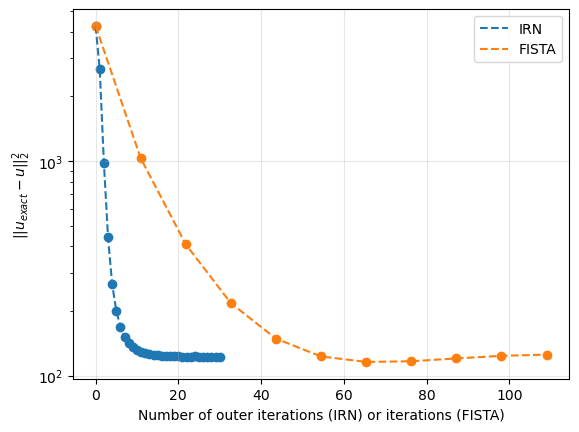

In [18]:
plt.scatter(np.linspace(0, len(err2) - 1, len(err2)), err2)
plt.semilogy(np.linspace(0, len(err2) - 1, len(err2)), err2, linestyle='--', label = 'IRN')
plt.semilogy(np.linspace(0, len(err_fista)*10 - 1, len(err_fista)), err_fista, label= 'FISTA', linestyle='--')
plt.scatter(np.linspace(0, len(err_fista)*10 - 1, len(err_fista)), err_fista)
plt.legend()
plt.xlabel('Number of outer iterations (IRN) or iterations (FISTA)')
plt.ylabel('$||u_{exact} - u||_2^2$')
plt.grid(alpha = 0.3)

outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 14 iterations
outer iteration: 3
cg converged in 48 iterations
outer iteration: 4
cg converged in 80 iterations
outer iteration: 5
cg converged in 93 iterations
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 36 iterations
outer iteration: 3
cg converged in 75 iterations
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 51 iterations
outer iteration: 3
cg converged in 90 iterations
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10


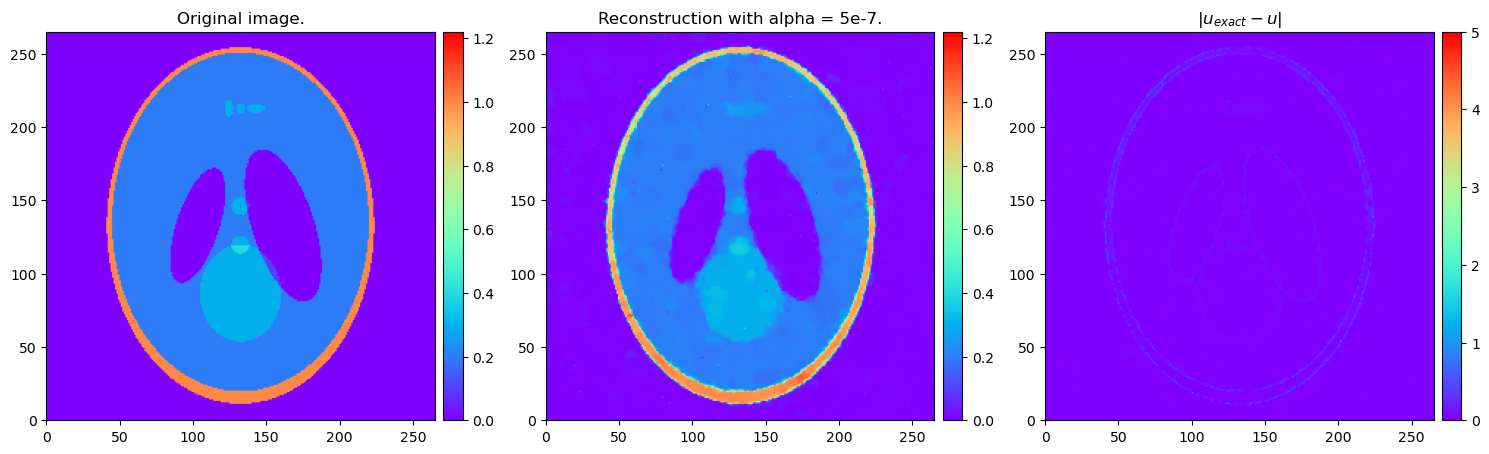

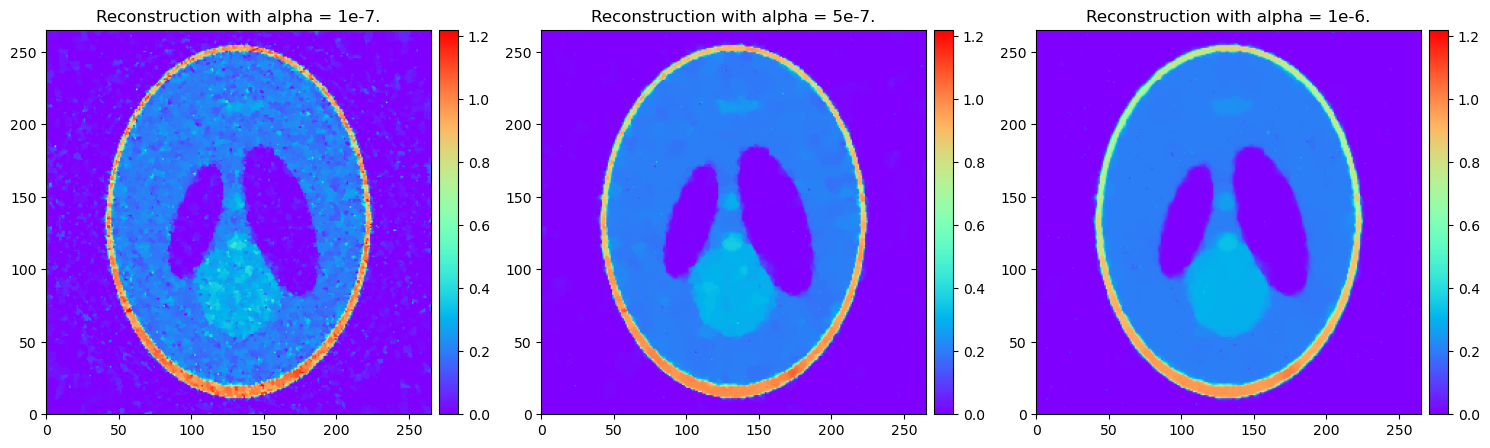

In [ ]:
A, sino, ig, ag, phantom = get_A(50, 265)
sino_noisy = add_poss_noise(20000, 50, 265)

import time

t2_start = time.time()
solsmall, err2, conv_arr2, inner_iter_arr2 = tv_solver_normal(initial = ig.allocate(0), 
                    inner_iter = 100, 
                    outer_iter = 10, 
                    A = A,
                    sino = sino_noisy, 
                    alpha = 1e-7, 
                    er = None, 
                    pre = "False", 
                    cg_tol = 1e-2, 
                    vox_size = None,
                    exact = phantom)
t2_end = time.time()

solmid, err2, conv_arr2, inner_iter_arr2 = tv_solver_normal(initial = ig.allocate(0), 
                    inner_iter = 100, 
                    outer_iter = 10, 
                    A = A,
                    sino = sino_noisy, 
                    alpha = 5e-7, 
                    er = None, 
                    pre = "False", 
                    cg_tol = 1e-2, 
                    vox_size = None,
                    exact = phantom)
t2_end = time.time()

sollarge, err2, conv_arr2, inner_iter_arr2 = tv_solver_normal(initial = ig.allocate(0), 
                    inner_iter = 100, 
                    outer_iter = 10, 
                    A = A,
                    sino = sino_noisy, 
                    alpha = 1e-6, 
                    er = None, 
                    pre = "False", 
                    cg_tol = 1e-2, 
                    vox_size = None,
                    exact = phantom)
t2_end = time.time()



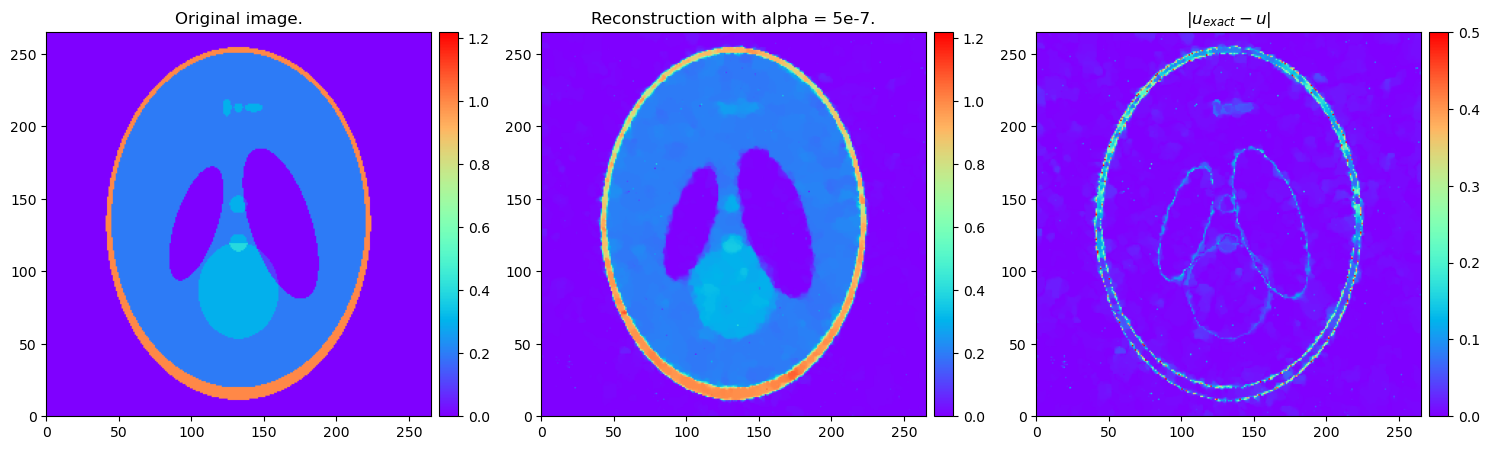

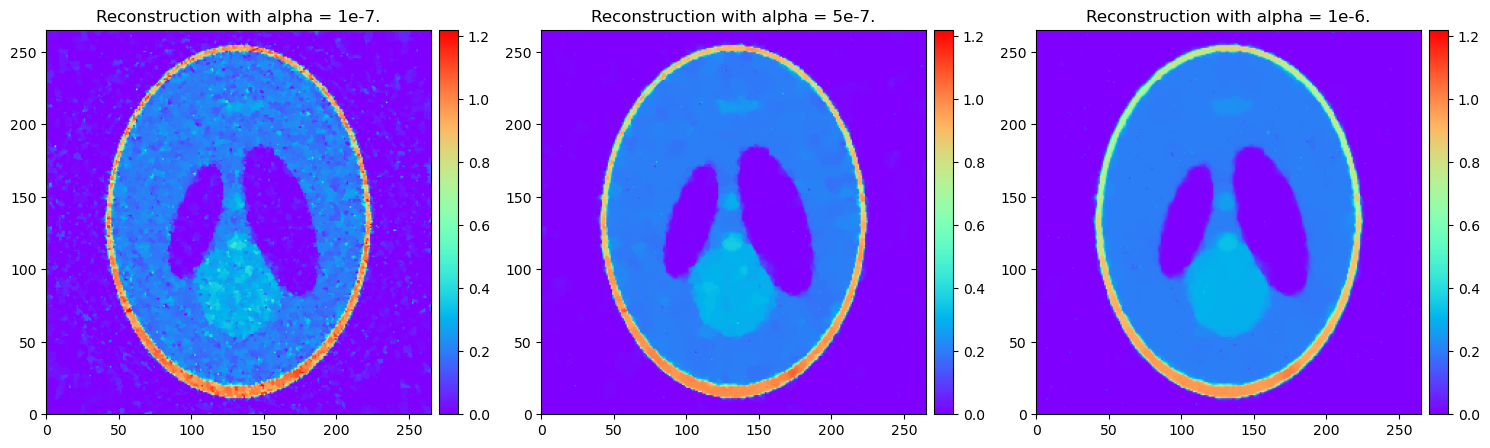

In [15]:
show2D([phantom, solmid.abs(), (phantom - solmid).abs()], ['Original image.', f'Reconstruction with alpha = 5e-7.', '$|u_{exact} - u|$'], num_cols = 3, 
           cmap = 'rainbow', fix_range = [(0,1.22), (0,1.22), (0,0.5)], axis_labels=('', ''))

show2D([solsmall, solmid, sollarge],['Reconstruction with alpha = 1e-7.', 'Reconstruction with alpha = 5e-7.', 'Reconstruction with alpha = 1e-6.'], num_cols = 3, 
       fix_range = (0, 1.22), 
       axis_labels=('',''), 
       cmap = 'rainbow')

Run results

In [33]:
A, sino, ig, ag, phantom = get_A(50, 265)
sino_noisy = add_poss_noise(20000, 50, 265)

import time

print("\n Computation with preconditioning \n")

t1_start = time.time()
sol, err, conv_arr, inner_iter_arr1 = tv_solver_normal(initial = ig.allocate(0), 
                       inner_iter = 100, 
                       outer_iter = 3, 
                       A = A,
                       sino = sino_noisy, 
                       alpha = 5e-7, 
                       er = None, 
                       pre = "True", 
                       cg_tol = 1e-4, 
                       vox_size = 1 / 265, 
                       exact = phantom)
t1_end = time.time()

print("\n Computation without preconditioning \n")

t2_start = time.time()
sol2, err2, conv_arr2, inner_iter_arr2 = tv_solver_normal(initial = ig.allocate(0), 
                       inner_iter = 100, 
                       outer_iter = 3, 
                       A = A,
                       sino = sino_noisy, 
                       alpha = 5e-7, 
                       er = None, 
                       pre = "False", 
                       cg_tol = 1e-4, 
                       vox_size = None, 
                       exact = phantom)
t2_end = time.time()


print("time with preconditioning", t1_end - t1_start)
print("time without preconditioning", t2_end - t2_start)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)



 Computation with preconditioning 

outer iteration: 1
cg converged in 6 iterations
outer iteration: 2
cg converged in 25 iterations
outer iteration: 3
cg converged in 37 iterations

 Computation without preconditioning 

outer iteration: 1
cg converged in 6 iterations
outer iteration: 2
cg converged in 81 iterations
outer iteration: 3
time with preconditioning 28.382566213607788
time without preconditioning 12.606784343719482


[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]


ValueError: x and y must be the same size

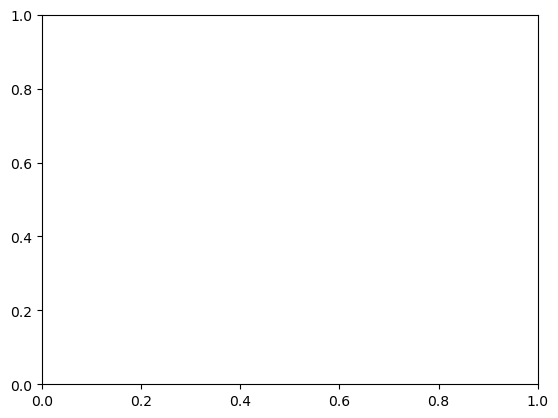

In [18]:
x = np.linspace(1,20,20)
print(x)

plt.figure()
plt.scatter(x, inner_iter_arr1)
plt.plot(x, inner_iter_arr1, linestyle='--', label='with preconditioning')
plt.scatter(x, inner_iter_arr2)
plt.plot(x, inner_iter_arr2, linestyle='--', label='without preconditioning')
plt.grid(alpha = 0.3)
plt.xlabel('outer iteration')
plt.ylabel('number of inner iterations')
#plt.title('Number of inner iterations needed to reach tolerance of 1e-2 for different outer iterations')
plt.legend()

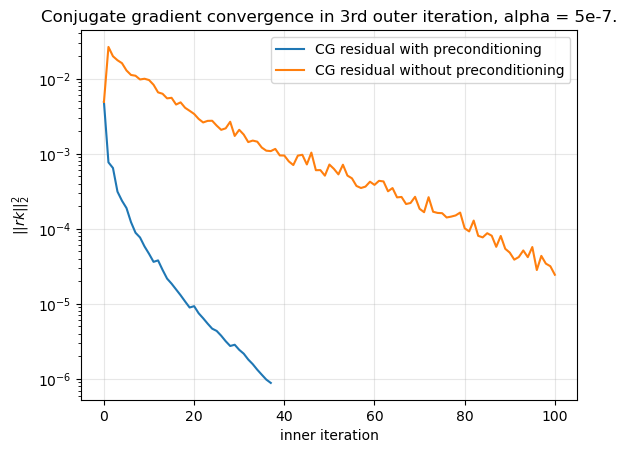

In [35]:
#plt.figure(figsize=(12, 8))
plt.semilogy(conv_arr, label='CG residual with preconditioning')
plt.semilogy(conv_arr2, label='CG residual without preconditioning')
plt.title(f"Conjugate gradient convergence in 3rd outer iteration, alpha = 5e-7.")
plt.legend()
plt.xlabel('inner iteration')
plt.ylabel("$||rk||_2^2$")
#plt.ylim(10**(-4), 0)
plt.grid(alpha = 0.3)

Comparing speed of fista, irls with cg and irls with pcg

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


pcg
outer iteration: 1
cg converged in 3 iterations
cg
outer iteration: 1
cg converged in 3 iterations
fista


  0%|          | 0/10 [00:00<?, ?it/s]

<class 'cil.framework.image_data.ImageData'> <class 'cil.framework.image_data.ImageData'>
pcg
outer iteration: 1
cg converged in 3 iterations
outer iteration: 2
cg converged in 12 iterations
cg
outer iteration: 1
cg converged in 3 iterations
outer iteration: 2
cg converged in 56 iterations
fista


  0%|          | 0/20 [00:00<?, ?it/s]

...

<class 'cil.framework.image_data.ImageData'> <class 'cil.framework.image_data.ImageData'>
pcg
outer iteration: 1
cg converged in 3 iterations
outer iteration: 2
cg converged in 12 iterations
outer iteration: 3
cg converged in 20 iterations
outer iteration: 4
cg converged in 22 iterations
outer iteration: 5
cg converged in 23 iterations
outer iteration: 6
cg converged in 22 iterations
outer iteration: 7
cg converged in 22 iterations
outer iteration: 8
cg converged in 20 iterations
outer iteration: 9
cg converged in 20 iterations
cg
outer iteration: 1
cg converged in 3 iterations
outer iteration: 2
cg converged in 56 iterations
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
fista


  0%|          | 0/90 [00:00<?, ?it/s]

<class 'cil.framework.image_data.ImageData'> <class 'cil.framework.image_data.ImageData'>
pcg
outer iteration: 1
cg converged in 3 iterations
outer iteration: 2
cg converged in 12 iterations
outer iteration: 3
cg converged in 20 iterations
outer iteration: 4
cg converged in 21 iterations
outer iteration: 5
cg converged in 22 iterations
outer iteration: 6
cg converged in 22 iterations
outer iteration: 7
cg converged in 22 iterations
outer iteration: 8
cg converged in 20 iterations
outer iteration: 9
cg converged in 20 iterations
outer iteration: 10
cg converged in 20 iterations
cg
outer iteration: 1
cg converged in 3 iterations
outer iteration: 2
cg converged in 56 iterations
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
fista


  0%|          | 0/100 [00:00<?, ?it/s]

<class 'cil.framework.image_data.ImageData'> <class 'cil.framework.image_data.ImageData'>


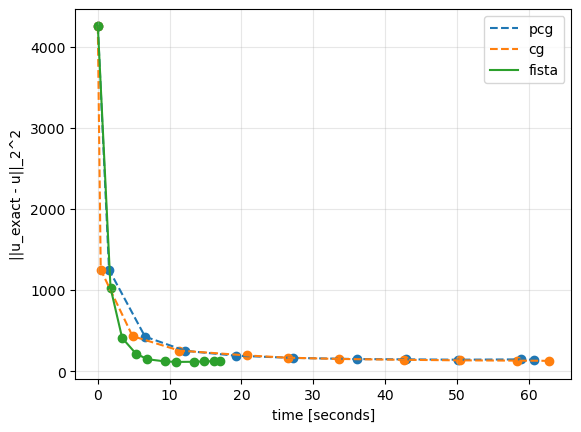

In [37]:
A, sino, ig, ag, phantom = get_A(50, 265)
sino_noisy = add_poss_noise(20000, 50, 265)
f1_poss = LeastSquares(A, sino_noisy, (1/2))
norm = L2NormSquared()

iterations = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
time_cg = []
time_pcg = []
time_fista = []

time_cg.append(0)
time_pcg.append(0)
time_fista.append(0)

err_cg = []
err_pcg = []
err_fista = []

initial_err = norm(phantom)
err_cg.append(initial_err)
err_pcg.append(initial_err)
err_fista.append(initial_err)

for it in iterations:

    print("pcg")
    t1_start = time.time()
    sol, err, conv_arr, lala = tv_solver_normal(initial = ig.allocate(0), 
                        inner_iter = 100, 
                        outer_iter = it, 
                        A = A,
                        sino = sino_noisy, 
                        alpha = 5e-7, 
                        er = None, 
                        pre = "True", 
                        cg_tol = 1e-3, 
                        vox_size = 1 / 265, 
                        exact = None)
    t1_end = time.time()

    time_pcg.append(t1_end - t1_start)
    err_pcg.append(norm(phantom - sol.abs()))

    print("cg")
    t2_start = time.time()
    sol2, err2, conv_arr2, lala = tv_solver_normal(initial = ig.allocate(0), 
                        inner_iter = 100, 
                        outer_iter = it, 
                        A = A,
                        sino = sino_noisy, 
                        alpha = 5e-7, 
                        er = None, 
                        pre = "False", 
                        cg_tol = 1e-3, 
                        vox_size = None, 
                        exact = None)
    t2_end = time.time()
    
    time_cg.append(t2_end - t2_start)
    err_cg.append(norm(phantom - sol2))

    print('fista')
    TV1 = FGP_TV(alpha=3e-4, nonnegativity=True, device='cpu')
    fista_TV1 = FISTA(initial=ig.allocate(0), f=f1_poss, g=TV1, update_objective_interval=10)

    t3_start = time.time()
    fista_TV1.run(it*10)
    t3_end = time.time()
    sol3 = fista_TV1.solution

    time_fista.append(t3_end - t3_start)
    print(type(sol3), type(sol2))
    err_fista.append(norm(sol3 - phantom))

    #show2D([sol.abs(), sol2.abs(), sol3], [f'pcg, time = {t1_end - t1_start}', f'cg, time = {t2_end - t2_start}', f'fista, time = {t3_end - t3_start}'], cmap='rainbow', num_cols = 3)
    #show2D([(sol.abs() - phantom).abs(), (sol2.abs() - phantom).abs(), (sol3 - phantom).abs()], ['error PCG', 'error CG', 'error fista'], num_cols = 3, cmap = 'rainbow')

#plt.figure(figsize=(12,8))
plt.plot(time_pcg, err_pcg, label="pcg", linestyle='--')
plt.scatter(time_pcg, err_pcg)
plt.plot(time_cg, err_cg, label="cg", linestyle='--')
plt.scatter(time_cg, err_cg)
plt.plot(time_fista, err_fista, label="fista")
plt.scatter(time_fista, err_fista)
plt.ylabel('||u_exact - u||_2^2')
plt.xlabel('time [seconds]')
plt.grid(alpha=0.3)
plt.legend()


fista 
 [0, 1.7675867080688477, 3.387190818786621, 5.293859243392944, 6.887581825256348, 9.323590278625488, 10.943089485168457, 13.323694944381714, 14.749590635299683, 16.113523721694946, 17.041971683502197] 
 [4254.370000000021, 1028.1875347211912, 410.3982347607882, 218.60483086123958, 148.50120653671178, 122.0660080575142, 115.23361691645778, 116.95471982388942, 121.15776872543124, 124.39631150594676, 125.65814682095872]
cg 
 [0, 0.4035952091217041, 4.832000970840454, 11.34286117553711, 20.825842142105103, 26.46465492248535, 33.61627912521362, 42.578773736953735, 50.39194202423096, 58.30864930152893, 62.78587889671326] 
 [4254.370000000021, 1251.2321392100228, 433.1639659260366, 255.16934154532896, 194.64505404146553, 167.2795405113979, 151.81887543315798, 141.25238864886825, 134.8382282878667, 131.2948248847796, 128.79288728260678]
pcg 
 [0, 1.5606305599212646, 6.571763277053833, 12.191360235214233, 19.189234018325806, 27.121215105056763, 36.065362215042114, 42.90334939956665, 50.1

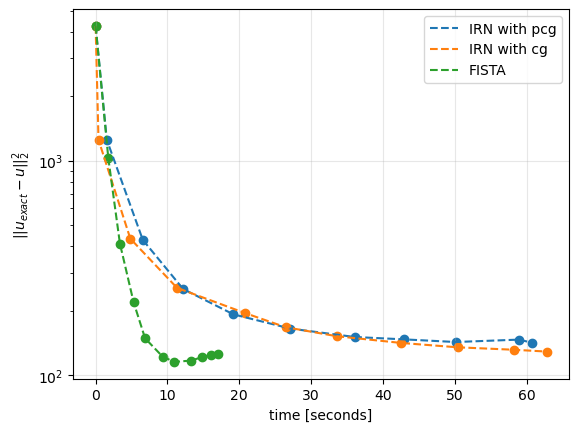

In [41]:

print("fista \n", time_fista, "\n", err_fista)
print("cg \n", time_cg, "\n", err_cg)
print("pcg \n", time_pcg, "\n", err_pcg)

#plt.figure(figsize=(12,8))
plt.semilogy(time_pcg, err_pcg, label="IRN with pcg", linestyle='--')
plt.scatter(time_pcg, err_pcg)
plt.semilogy(time_cg, err_cg, label="IRN with cg", linestyle='--')
plt.scatter(time_cg, err_cg)
plt.semilogy(time_fista, err_fista, label="FISTA", linestyle='--')
plt.scatter(time_fista, err_fista)
plt.ylabel('$||u_{exact} - u||_2^2$')
plt.xlabel('time [seconds]')
plt.grid(alpha=0.3)
plt.legend()

## Preconditioning the one norm

In [ ]:
def apply_operator_onenorm(x, W, A, alpha):

    """
    Applies the operator 
    
    A^TA + alpha * W 
    
    to the input ImageData x. Used to solve the normal equations 

    (R^TR + alpha * W_k)u = R^Ty

    with W_k = u_k**(-1)

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * W)x
    """
    
    # z2 = (A^TA)x
    z1 = A.direct(x)
    z2 = A.adjoint(z1)

    # z3 = Wx
    w_operator = DiagonalOperator(W)
    z3 = w_operator.direct(x)

    z = z2 + alpha * z3

    return z

def inverse_pre(ATAI_mean, uk_abs, alpha, ig):
    temp1 = (1/alpha) * uk_abs

    inverse_mean = (1/ATAI_mean)
    temp2 = ig.allocate()
    temp2.fill(inverse_mean)

    inverse_preconditioner = DiagonalOperator(temp1 + temp2)

    return inverse_preconditioner

def GC_one_preconditioned(initial, uk_abs, max_iter, A, ATb, alpha, Wk, cg_tol, ATAI_mean):
       
       """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG

    preconditioned

    """
       u0 = initial.copy()
       r0 = ATb - apply_operator_onenorm(u0, Wk, A, alpha)
       get_ig = A.domain_geometry()

       n_pixels = int(np.sqrt(np.size(u0)))
       inv_pre_Wk = inverse_pre(ATAI_mean, uk_abs, alpha, get_ig)
       w0 = inv_pre_Wk.direct(r0)
       p0 = w0

        # set initials, note these are all of class <ImageData>
       wk = w0
       pk = p0
       uk = u0
       rk = r0

       delta_new = rk.dot(wk.conjugate())

       # needed for stopping criteria later
       norm = L2NormSquared()
       r0_norm = norm(r0)
       tol = cg_tol

        # to check convergence
       conv_arr = []
       conv_arr.append(r0_norm)

        # perform CG iterations
       for k in range(max_iter):
        zk = apply_operator_onenorm(pk, Wk, A, alpha)

        alpha_k = delta_new / (pk.dot(zk.conjugate()))

        uk_plus_one = uk + alpha_k * pk
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        wk_plus_one = inv_pre_Wk.direct(rk_plus_one)
        delta_new = wk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new / delta_old

        pk_plus_one = wk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  
        conv_arr.append(check)
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k + 1} iterations")
            break

        # reset variables
        rk = rk_plus_one 
        pk = pk_plus_one
        uk = uk_plus_one
    
       return uk, conv_arr
    

In [ ]:
def onenorm_normal(initial, inner_iter, outer_iter, A, b, alpha, er, pre, cg_tol):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * ||u||_1

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha*W_k)u = A^Tb

    In each outer iterations the matrix W_k is updated (reweighted), W_k = u_k^(-1)

    Input:
        max_outer:  Number of outer iterations (scalar)
        max_inner:  Number of CG interations (scalar)
        initial:    Initial guess for u (ImageData)
        A:          The acting operator (Operator)
        b:          The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        er:         Upper bound for 'small values' in W_k that will be set to zero (float)

    Output:
        uk:         Reconstructed image (ImageData)
    """

    # setting up LHS of normal equation
    uk = initial.copy()
    lhs = A.adjoint(b)
    n_pixels = int(np.sqrt(np.size(uk)))

    if pre == "True":
        ATAI_mean = mean_ATA(A, n_pixels)
        #ATAI_mean = exact_norm

    get_ig = A.domain_geometry()

    if er is None:
        er_use = 0.01*sino.max()
    else:
        er_use = er

    for k in range(outer_iter):

        print(f"outer iteration: {k+1}")
        
        ## reweight the regularisation term ##
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = uk_grad_np[large_values] ** (-1)

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        if pre == "True":
            # preconditioner requires 1/W_k, which is the same as not inverting uk in the first place
            uk_for_precon = np.zeros_like(uk.as_array())
            uk_for_precon[large_values] = uk_grad_np[large_values]
            uk_for_precon_id = get_ig.allocate()
            uk_for_precon_id.fill(uk_for_precon)


        # performing CG
        if pre == "True":
            cg_output, conv_arr = GC_one_preconditioned(uk, uk_for_precon_id, inner_iter, A, lhs, alpha, uk_reweighted, cg_tol, ATAI_mean)
        else:
            cg_output, conv_arr = CG(uk, inner_iter, A, lhs, alpha, uk_reweighted, cg_tol, apply_operator_onenorm)


        uk = cg_output

    return uk, conv_arr

In [ ]:
A, sino, ig, ag, phantom = get_A(20,100)
sino_noisy = add_poss_noise(20000, 20, 100)
import time

print("Computation with preconditioning")
t0 = time.time()
sol1, conv_arr1 = onenorm_normal(initial = ig.allocate(0), 
                     inner_iter = 100,
                     outer_iter = 3,  
                    A = A, 
                    b = sino_noisy, 
                    alpha = 0.0008, 
                    er = 0.0001, 
                    pre = "True", 
                    cg_tol = 1e-16)
t1 = time.time()

print("Computation without preconditioning")
t2 = time.time()
sol2, conv_arr2 = onenorm_normal(initial = ig.allocate(0), 
                     inner_iter = 100,
                     outer_iter = 3,  
                    A = A, 
                    b = sino_noisy, 
                    alpha = 0.0008, 
                    er = 0.0001, 
                    pre = "False", 
                    cg_tol = 1e-16)
t3 = time.time()

print("time with preconditioing", t1 - t0)
print("time without preconditioning", t3 - t2)

Computation with preconditioning
outer iteration: 1
outer iteration: 2
outer iteration: 3
Computation without preconditioning
outer iteration: 1
outer iteration: 2
outer iteration: 3
time with preconditioing 1.7435009479522705
time without preconditioning 1.6801083087921143


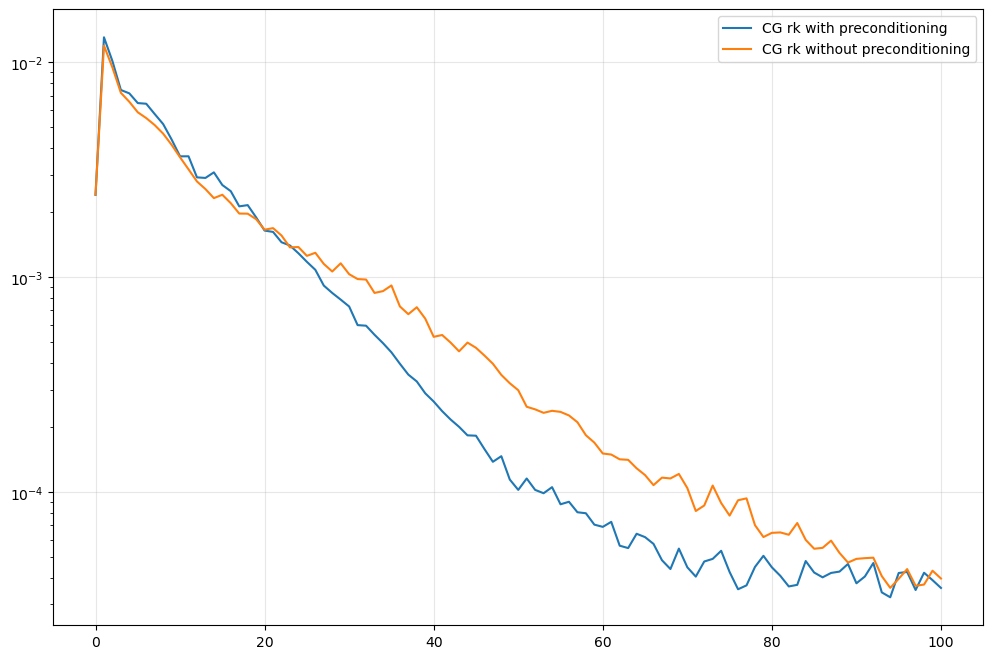

In [ ]:
plt.figure(figsize=(12,8))
plt.semilogy(conv_arr1, label="CG rk with preconditioning")
plt.semilogy(conv_arr2, label="CG rk without preconditioning")
plt.legend()
plt.grid(alpha = 0.3)

<class 'cil.framework.image_data.ImageData'>


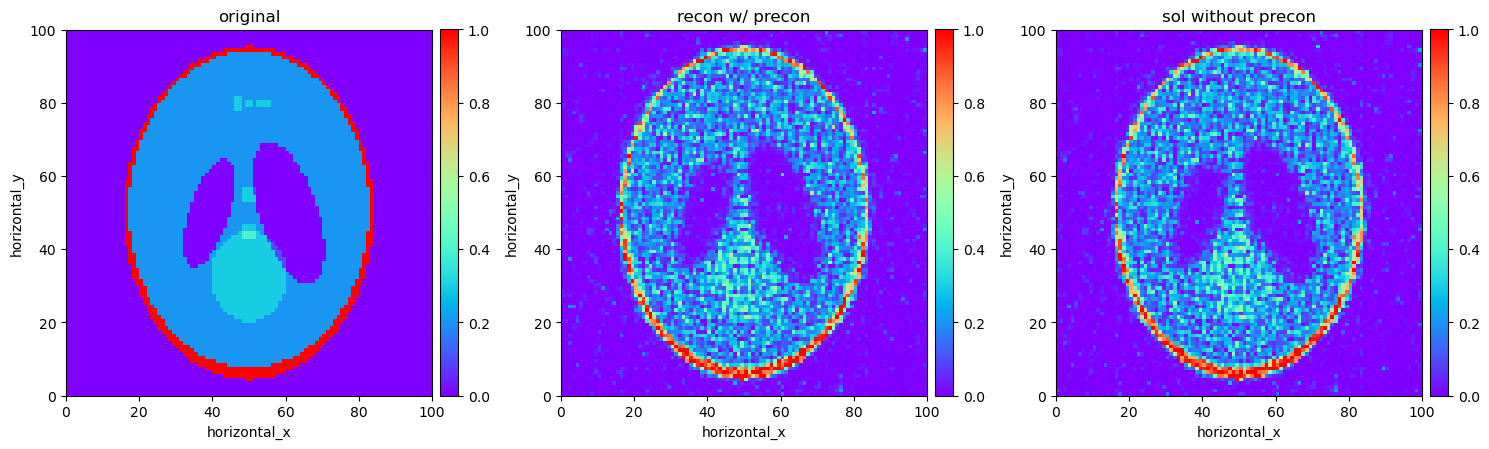

In [ ]:
print(type(sol))

show2D([phantom, sol1, sol2], ['original', 'recon w/ precon', 'sol without precon'], 
       fix_range= (0,1), 
       cmap = "rainbow",
       num_cols=3)